<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/Exercicio_1_1_Heart_Failure_Classificacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizagem de Máquina (Turma ME)  
PPGIa - Programa de Pós-Graduação em Informática - PUCPR - Pontifícia Universidade Católica do Paraná  
Turma: PPGIa (404) 2026/02  
Professor: Alceu de Souza Britto Jr. (alceu@ppgia.pucpr.br)  
Aluno(a): 40131556 - Kelly Christine Alvarenga de Castro (christine.kelly@pucpr.edu.br)  

# Exercício 1.1 — Classificação da base Heart Failure

**Objetivo:** treinar e avaliar modelos preditivos rasos para a tarefa de classificação binária da base *Heart Failure Clinical Records*.

**Modelo principal exigido:** Árvore de Decisão, por ser um modelo caixa branca, isto é, mais facilmente explicável por regras.

**Modelos de comparação:** SVM, MLP e ensembles.

> Observação: este notebook foi estruturado para baixar a base diretamente pelo `kagglehub`.

## 1. Conceito estudados

Este exercício é um problema de **aprendizagem supervisionada** para **classificação binária**.

A base contém atributos clínicos de pacientes, como idade, fração de ejeção, creatinina sérica, plaquetas, pressão alta, tabagismo e tempo de acompanhamento.

O atributo alvo é:

```text
DEATH_EVENT
```

Com a seguinte interpretação:

| Classe | Significado |
|---|---|
| 0 | paciente vivo |
| 1 | paciente falecido durante o período de acompanhamento |

A tarefa é aprender uma função:

$$
y = f(X)
$$

em que:

- $X$ representa os atributos clínicos de entrada;
- $y$ representa a classe prevista: vivo ou óbito.

A **Árvore de Decisão** será usada como modelo principal porque permite explicar a decisão por meio de regras do tipo:

```text
se atributo <= valor, siga para o ramo esquerdo;
caso contrário, siga para o ramo direito.
```

Depois, comparamos a Árvore de Decisão com SVM, MLP e ensembles para verificar se modelos mais complexos melhoram o desempenho.

## 2. Fórmulas necessárias

### 2.1 Impureza Gini

A Árvore de Decisão pode usar o índice Gini para escolher divisões nos nós.

$$
Gini(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

Onde:

- $S$ é o conjunto de exemplos no nó;
- $c$ é o número de classes;
- $p_i$ é a proporção de exemplos da classe $i$ no nó.

Quanto menor o Gini, mais puro é o nó.

---

### 2.2 Entropia

Outra opção é a entropia:

$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
$$

---

### 2.3 Métricas de avaliação

Acurácia:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Precisão da classe óbito:

$$
Precision = \frac{TP}{TP + FP}
$$

Recall da classe óbito:

$$
Recall = \frac{TP}{TP + FN}
$$

F1-score:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

Para este problema, o **recall da classe 1** é especialmente importante, porque a classe 1 representa óbito. Um falso negativo significa que o paciente faleceu, mas o modelo previu como vivo.

## 3. Resolução

### 3.1 Importação das bibliotecas



In [1]:
# Bibliotecas gerais
import os
import glob
import inspect
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# KaggleHub para baixar a base diretamente do Kaggle
import kagglehub

# Scikit-learn
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Versão do scikit-learn:", sklearn.__version__)

Versão do scikit-learn: 1.6.1


### 3.2 Download da base pelo KaggleHub

A base será baixada diretamente do Kaggle pelo identificador:

```text
andrewmvd/heart-failure-clinical-data
```

In [2]:
# Baixar a base Heart Failure Clinical Data pelo KaggleHub
dataset_path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

print("Base baixada em:", dataset_path)

# Procurar arquivos CSV dentro da pasta baixada
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)

print("Arquivos CSV encontrados:")
for file in csv_files:
    print("-", file)

if len(csv_files) == 0:
    raise FileNotFoundError("Nenhum arquivo CSV foi encontrado na pasta baixada pelo KaggleHub.")

# Selecionar o arquivo CSV principal da base
csv_path = csv_files[0]
print("\nArquivo selecionado:", csv_path)

100%|██████████| 3.97k/3.97k [00:00<00:00, 7.52MB/s]

Extracting files...
Base baixada em: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1
Arquivos CSV encontrados:
- /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1/heart_failure_clinical_records_dataset.csv

Arquivo selecionado: /root/.cache/kagglehub/datasets/andrewmvd/heart-failure-clinical-data/versions/1/heart_failure_clinical_records_dataset.csv


### 3.3 Carregamento e inspeção inicial da base

In [3]:
# Carregar a base em um DataFrame
heart_df = pd.read_csv(csv_path)

# Visualizar as primeiras linhas
heart_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
# Dimensão da base
print("Dimensão da base:", heart_df.shape)

# Tipos das colunas
print("\nTipos dos atributos:")
print(heart_df.dtypes)

# Quantidade de valores ausentes por coluna
print("\nValores ausentes por coluna:")
print(heart_df.isna().sum())

Dimensão da base: (299, 13)

Tipos dos atributos:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Valores ausentes por coluna:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


## Representação do Problema  
### Atributos de entrada (12, integers/booleans)
•	age: the age of the patient  
•	anaemia:  decrease of red blood cells or hemoglobin (boolean)  
•	creatinine_phosphokinase: Level of the CPK enzyme in the blood (mcg/L)  
•	diabetes: if the patient has diabetes (boolean)  
•	ejection_fraction: percentage of blood leaving the heart at each contraction (percentage)  
•	high_blood_pressure: if the patient has hypertension (boolean)  
•	platelets: platelets in the blood (kiloplatelets/mL)  
•	serum_creatinine: level of serum creatinine in the blood (mg/dL)  
•	serum_sodium: level of serum sodium in the blood (mEq/L)  
•	sex: woman or man (binary)  
•	smoking: if the patient smokes or not (boolean)  
•	time: follow-up period (days)  
  
**Atributo alvo** (0-alive, 1- deceased)  
– Classificação Binária  
- death_event - If the patient deceased during the follow-up period (boolean)


### 3.4 Distribuição da variável alvo

Antes de treinar, é necessário verificar se a base está balanceada ou desbalanceada.

In [5]:
# Contagem absoluta das classes
classe_contagem = heart_df["DEATH_EVENT"].value_counts().sort_index()

# Distribuição percentual das classes
classe_percentual = heart_df["DEATH_EVENT"].value_counts(normalize=True).sort_index() * 100

classes_df = pd.DataFrame({
    "classe": classe_contagem.index,
    "quantidade": classe_contagem.values,
    "percentual": classe_percentual.round(2).values
})

classes_df["interpretação"] = classes_df["classe"].map({0: "vivo", 1: "óbito"})

display(classes_df)

,classe,quantidade,percentual,interpretação
0,0,203,67.89,vivo
1,1,96,32.11,óbito


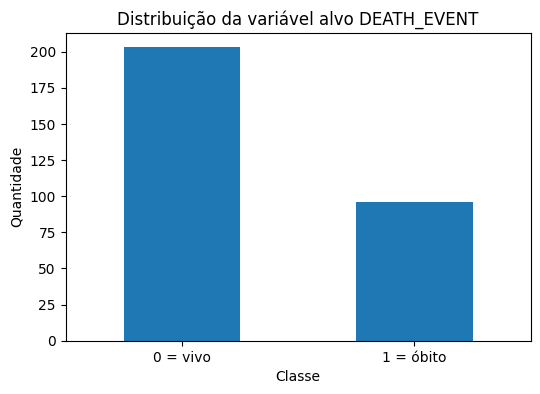

In [6]:
# Gráfico simples da distribuição das classes
ax = classe_contagem.plot(kind="bar", figsize=(6, 4))
plt.title("Distribuição da variável alvo DEATH_EVENT")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.xticks(ticks=[0, 1], labels=["0 = vivo", "1 = óbito"], rotation=0)
plt.show()

A base é moderadamente desbalanceada, pois há mais pacientes vivos do que falecidos.

### 3.5 Separação entre atributos de entrada e atributo alvo

In [7]:
# Separar atributos de entrada e alvo
X = heart_df.drop(columns=["DEATH_EVENT"])
y = heart_df["DEATH_EVENT"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

print("\nAtributos de entrada:")
print(list(X.columns))

Formato de X: (299, 12)
Formato de y: (299,)

Atributos de entrada:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


### 3.6 Separação treino/teste

Usaremos 80% da base para treino e 20% para teste.

Como a base tem desbalanceamento entre as classes, usamos `stratify=y` para manter proporções semelhantes de vivos e óbitos no treino e no teste.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Treino: (239, 12) (239,)
Teste: (60, 12) (60,)

Distribuição no treino:
DEATH_EVENT
0    0.678
1    0.322
Name: proportion, dtype: float64

Distribuição no teste:
DEATH_EVENT
0    0.683
1    0.317
Name: proportion, dtype: float64


### 3.7 Validação cruzada e função de avaliação

Usaremos validação cruzada estratificada com 5 folds para ajustar hiperparâmetros.

A métrica usada no `GridSearchCV` será o **F1-score da classe 1**, para equilibrar precisão e recall para óbito.

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


def avaliar_classificador(nome_modelo, modelo, X_test, y_test):
    """
    Avalia um classificador no conjunto de teste.
    Retorna um dicionário com as principais métricas.
    """
    y_pred = modelo.predict(X_test)

    # Alguns modelos possuem predict_proba; outros podem não possuir.
    try:
        y_proba = modelo.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    except Exception:
        roc_auc = np.nan

    return {
        "Modelo": nome_modelo,
        "Acurácia_teste": accuracy_score(y_test, y_pred),
        "Precisão_óbito": precision_score(y_test, y_pred, zero_division=0),
        "Recall_óbito": recall_score(y_test, y_pred, zero_division=0),
        "F1_óbito": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc
    }

### 3.8 Definição dos modelos e grades de hiperparâmetros

A Árvore de Decisão é o modelo principal.

SVM e MLP usam `StandardScaler`, pois são sensíveis à escala dos atributos.

Random Forest, Bagging e AdaBoost são usados como modelos ensemble de comparação.

In [10]:
# Compatibilidade do BaggingClassifier entre versões do scikit-learn:
# Dica do professor Alceu ;) --> versões recentes usam "estimator"; versões antigas usam "base_estimator".
if "estimator" in inspect.signature(BaggingClassifier).parameters:
    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    )
    bagging_params = {
        "n_estimators": [50],
        "estimator__max_depth": [3, None]
    }
else:
    bagging_model = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    )
    bagging_params = {
        "n_estimators": [50],
        "base_estimator__max_depth": [3, None]
    }

models_params = {
    "Árvore de Decisão": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "criterion": ["gini", "entropy"],
            "max_depth": [2, 3, 4, None],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [None, "balanced"]
        }
    ),

    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=RANDOM_STATE))
        ]),
        {
            "model__kernel": ["linear", "rbf"],
            "model__C": [0.1, 1, 10],
            "model__class_weight": [None, "balanced"]
        }
    ),

    "MLP": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                max_iter=500,
                early_stopping=True,
                random_state=RANDOM_STATE
            ))
        ]),
        {
            "model__hidden_layer_sizes": [(20,), (50,)],
            "model__alpha": [0.0001, 0.01]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [100],
            "max_depth": [3, 5, None],
            "min_samples_leaf": [1, 2],
            "class_weight": [None, "balanced"]
        }
    ),

    "Bagging AD": (
        bagging_model,
        bagging_params
    ),

    "AdaBoost": (
        AdaBoostClassifier(random_state=RANDOM_STATE),
        {
            "n_estimators": [50, 100],
            "learning_rate": [0.1, 1.0]
        }
    )
}

### 3.9 Treinamento e busca de hiperparâmetros

Esta célula treina todos os modelos e seleciona a melhor configuração com `GridSearchCV`.

Como a base é pequena, a execução deve ser relativamente rápida.

In [11]:
resultados = []
melhores_modelos = {}
melhores_parametros = {}

for nome, (modelo, parametros) in models_params.items():
    print(f"Treinando: {nome}")

    grid = GridSearchCV(
        estimator=modelo,
        param_grid=parametros,
        scoring="f1",      # foco na classe 1, óbito
        cv=cv,
        refit=True,
        n_jobs=1           # mais estável em notebooks/Colab
    )

    grid.fit(X_train, y_train)

    metricas = avaliar_classificador(nome, grid.best_estimator_, X_test, y_test)
    metricas["CV_F1_médio"] = grid.best_score_
    metricas["Melhores parâmetros"] = grid.best_params_

    resultados.append(metricas)
    melhores_modelos[nome] = grid.best_estimator_
    melhores_parametros[nome] = grid.best_params_

    print(f"Concluído: {nome}")
    print("Melhores parâmetros:", grid.best_params_)
    print("Melhor F1 médio na validação cruzada:", round(grid.best_score_, 4))
    print("-" * 80)

resultados_df = pd.DataFrame(resultados)

# Reorganizar colunas
resultados_df = resultados_df[[
    "Modelo",
    "CV_F1_médio",
    "Acurácia_teste",
    "Precisão_óbito",
    "Recall_óbito",
    "F1_óbito",
    "ROC_AUC",
    "Melhores parâmetros"
]]

# Ordenar pelo F1 da classe óbito
resultados_df = resultados_df.sort_values(
    by=["F1_óbito", "Recall_óbito", "Acurácia_teste"],
    ascending=False
).reset_index(drop=True)

# Arredondar apenas para exibição
resultados_exibicao = resultados_df.copy()
for col in ["CV_F1_médio", "Acurácia_teste", "Precisão_óbito", "Recall_óbito", "F1_óbito", "ROC_AUC"]:
    resultados_exibicao[col] = resultados_exibicao[col].round(3)

display(resultados_exibicao)

Treinando: Árvore de Decisão
Concluído: Árvore de Decisão
Melhores parâmetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2}
Melhor F1 médio na validação cruzada: 0.7379
--------------------------------------------------------------------------------
Treinando: SVM
Concluído: SVM
Melhores parâmetros: {'model__C': 1, 'model__class_weight': None, 'model__kernel': 'linear'}
Melhor F1 médio na validação cruzada: 0.7365
--------------------------------------------------------------------------------
Treinando: MLP
Concluído: MLP
Melhores parâmetros: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (20,)}
Melhor F1 médio na validação cruzada: 0.4873
--------------------------------------------------------------------------------
Treinando: Random Forest
Concluído: Random Forest
Melhores parâmetros: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}
Melhor F1 médio na validação cruzada: 0.7762
--------

,Modelo,CV_F1_médio,Acurácia_teste,Precisão_óbito,Recall_óbito,F1_óbito,ROC_AUC,Melhores parâmetros
0,Random Forest,0.776,0.833,0.800,0.632,0.706,0.905,"{'class_weight': 'balanced', 'max_depth': None..."
1,Árvore de Decisão,0.738,0.767,0.609,0.737,0.667,0.773,"{'class_weight': 'balanced', 'criterion': 'gin..."
2,Bagging AD,0.714,0.833,0.909,0.526,0.667,0.899,"{'estimator__max_depth': 3, 'n_estimators': 50}"
3,AdaBoost,0.748,0.817,0.900,0.474,0.621,0.864,"{'learning_rate': 0.1, 'n_estimators': 50}"
4,SVM,0.736,0.783,0.800,0.421,0.552,0.856,"{'model__C': 1, 'model__class_weight': None, '..."
5,MLP,0.487,0.317,0.317,1.000,0.481,0.570,"{'model__alpha': 0.0001, 'model__hidden_layer_..."


O modelo com maior desempenho geral é o **Random Forest**. Porém, a **Árvore de Decisão** continua sendo o modelo principal do exercício por ser explicável.

### 3.10 Avaliação detalhada da Árvore de Decisão

Agora avaliamos em detalhes o modelo solicitado pelo enunciado: **Árvore de Decisão**.

In [12]:
modelo_ad = melhores_modelos["Árvore de Decisão"]

print("Melhores parâmetros da Árvore de Decisão:")
print(melhores_parametros["Árvore de Decisão"])

y_pred_ad = modelo_ad.predict(X_test)

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred_ad))

print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred_ad,
    target_names=["vivo_0", "óbito_1"],
    zero_division=0
))

Melhores parâmetros da Árvore de Decisão:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2}

Matriz de confusão:
[[32  9]
 [ 5 14]]

Relatório de classificação:
              precision    recall  f1-score   support

      vivo_0       0.86      0.78      0.82        41
     óbito_1       0.61      0.74      0.67        19

    accuracy                           0.77        60
   macro avg       0.74      0.76      0.74        60
weighted avg       0.78      0.77      0.77        60



### 3.11 Visualização da matriz de confusão

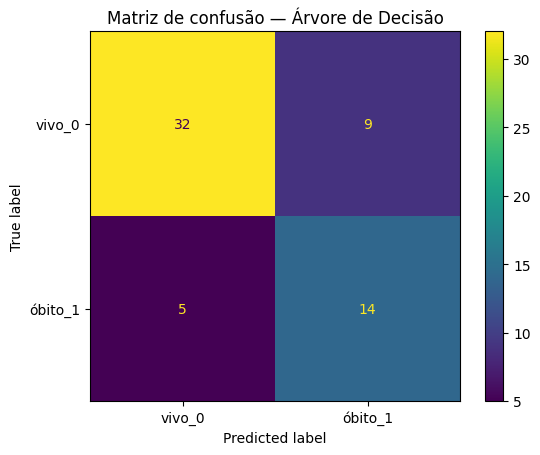

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ad,
    display_labels=["vivo_0", "óbito_1"]
)
plt.title("Matriz de confusão — Árvore de Decisão")
plt.show()

**Interpretação da matriz:**

| Célula | Interpretação |
|---|---|
| 32 | pacientes vivos classificados corretamente como vivos |
| 9 | pacientes vivos classificados incorretamente como óbito |
| 5 | pacientes falecidos classificados incorretamente como vivos |
| 14 | pacientes falecidos classificados corretamente como óbito |

O erro mais crítico é o valor **5**, pois representa falsos negativos para óbito.

### 3.12 Importância dos atributos na Árvore de Decisão

In [14]:
importancias_df = pd.DataFrame({
    "atributo": X.columns,
    "importancia": modelo_ad.feature_importances_
}).sort_values(by="importancia", ascending=False)

importancias_df["importancia"] = importancias_df["importancia"].round(4)

display(importancias_df)

,atributo,importancia
11,time,0.4856
7,serum_creatinine,0.1685
2,creatinine_phosphokinase,0.0941
4,ejection_fraction,0.0753
8,serum_sodium,0.0623
6,platelets,0.0573
0,age,0.0377
5,high_blood_pressure,0.0192
1,anaemia,0.0000
3,diabetes,0.0000


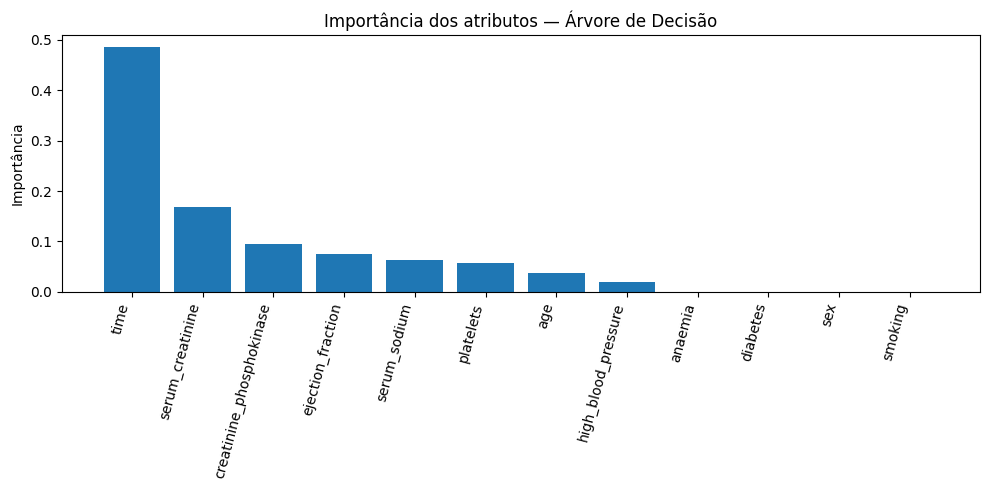

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(importancias_df["atributo"], importancias_df["importancia"])
plt.title("Importância dos atributos — Árvore de Decisão")
plt.ylabel("Importância")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

O atributo `time` tende a aparecer como o mais importante. Ele representa o período de acompanhamento e, por isso, deve ser interpretado com cautela.

### 3.13 Regras textuais da Árvore de Decisão

As regras a seguir, começando por divisões em atributos como `time`, `serum_creatinine`, `ejection_fraction` e outros ajudam a justificar a escolha da Árvore de Decisão como modelo caixa branca.

In [16]:
regras_ad = export_text(
    modelo_ad,
    feature_names=list(X.columns),
    max_depth=4
)

print(regras_ad)

|--- time <= 73.50
|   |--- time <= 52.00
|   |   |--- platelets <= 299500.00
|   |   |   |--- time <= 32.50
|   |   |   |   |--- serum_creatinine <= 0.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- serum_creatinine >  0.95
|   |   |   |   |   |--- class: 1
|   |   |   |--- time >  32.50
|   |   |   |   |--- age <= 70.00
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- age >  70.00
|   |   |   |   |   |--- class: 1
|   |   |--- platelets >  299500.00
|   |   |   |--- platelets <= 307500.00
|   |   |   |   |--- class: 0
|   |   |   |--- platelets >  307500.00
|   |   |   |   |--- creatinine_phosphokinase <= 85.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- creatinine_phosphokinase >  85.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |--- time >  52.00
|   |   |--- ejection_fraction <= 30.00
|   |   |   |--- class: 1
|   |   |--- ejection_fraction >  30.00
|   |   |   |--- serum_sodium <= 134.50
|   |   |   | 

### 3.14 Visualização da Árvore de Decisão

Para manter a figura legível, exibimos apenas os primeiros níveis da árvore.

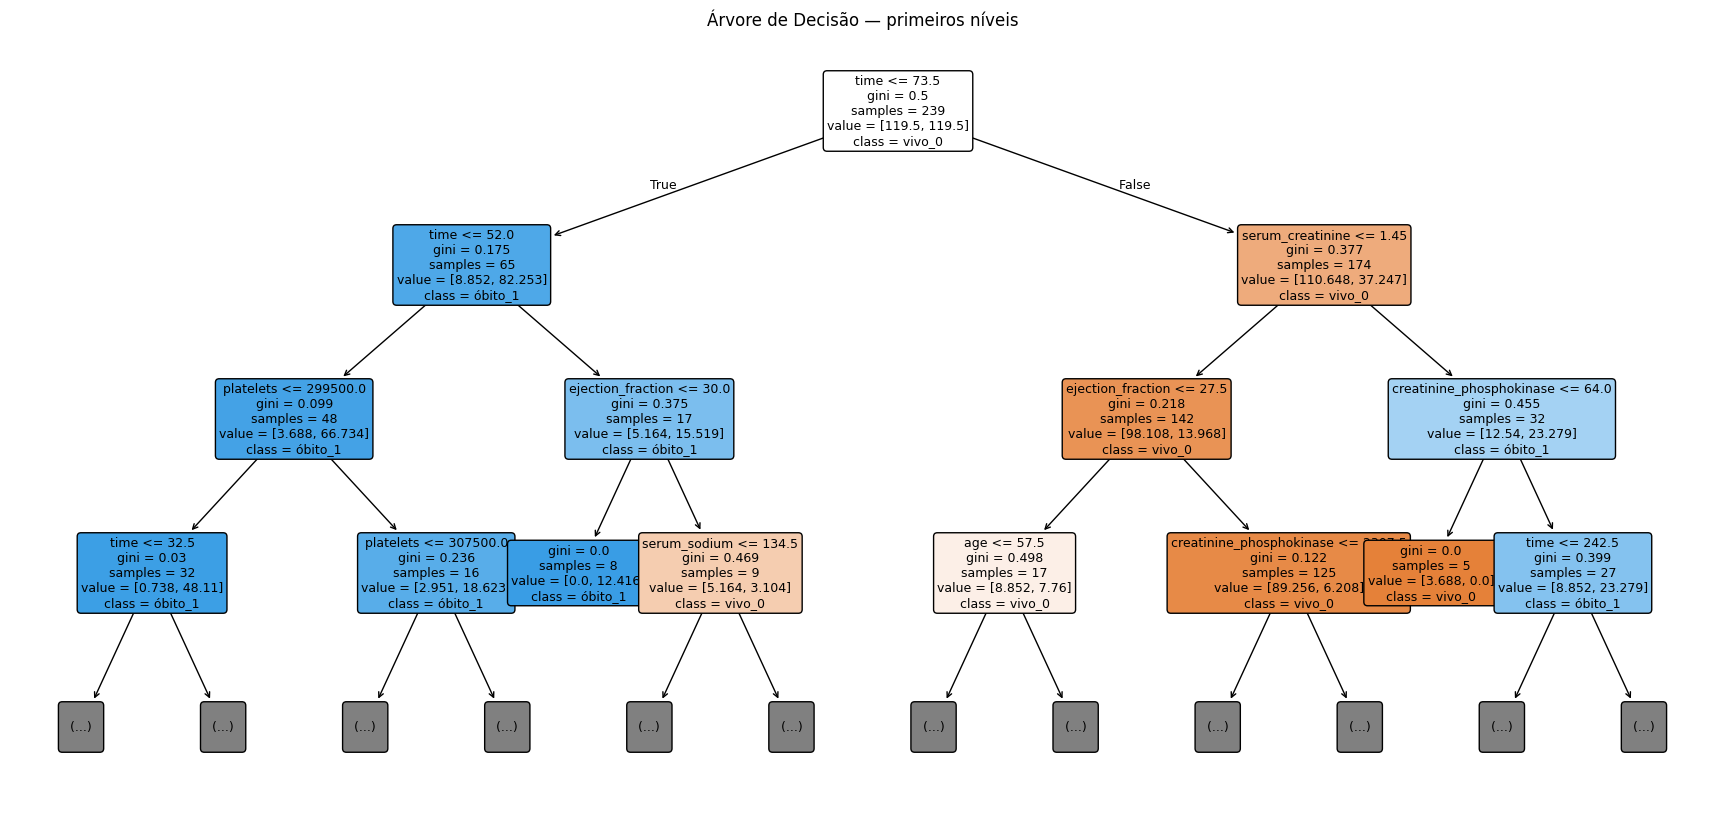

In [17]:
plt.figure(figsize=(22, 10))
plot_tree(
    modelo_ad,
    feature_names=list(X.columns),
    class_names=["vivo_0", "óbito_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Árvore de Decisão — primeiros níveis")
plt.show()

### 3.15 Salvando os resultados

Esta célula salva a tabela de resultados em CSV para uso no relatório.

In [18]:
resultados_df.to_csv("resultados_heart_failure_classificacao.csv", index=False)
importancias_df.to_csv("importancias_arvore_decisao_heart_failure.csv", index=False)

print("Arquivos salvos:")
print("- resultados_heart_failure_classificacao.csv")
print("- importancias_arvore_decisao_heart_failure.csv")

Arquivos salvos:
- resultados_heart_failure_classificacao.csv
- importancias_arvore_decisao_heart_failure.csv


## 4. Interpretação

A base possui 299 pacientes, 12 atributos de entrada e uma variável alvo binária, `DEATH_EVENT`.

A distribuição das classes indica aproximadamente:

- 67,9% pacientes vivos;
- 32,1% pacientes falecidos.

Portanto, a base não é perfeitamente balanceada. Por isso, a análise não deve depender apenas da acurácia. O **F1-score** e o **recall da classe óbito** são fundamentais.

Na execução, o melhor desempenho geral tende a ser do **Random Forest**, com acurácia aproximada de 0,833 e F1-score da classe óbito próximo de 0,706.

A **Árvore de Decisão**, modelo principal solicitado, apresentou:

- acurácia aproximada: 0,767;
- precisão para óbito: 0,609;
- recall para óbito: 0,737;
- F1-score para óbito: 0,667.

Apesar de o Random Forest ter desempenho geral superior, a Árvore de Decisão é mais adequada para a exigência de explicabilidade. Ela permite identificar quais atributos conduziram a decisão e visualizar regras de classificação.

A matriz de confusão esperada da Árvore de Decisão é:

$$
\begin{bmatrix}
32 & 9 \\
5 & 14
\end{bmatrix}
$$

Isto significa que, no conjunto de teste, a árvore classificou corretamente 14 dos 19 pacientes da classe óbito, mas deixou de identificar 5 óbitos.

## 5. Resposta final

A tarefa foi resolvida como um problema de **classificação supervisionada binária**, usando `DEATH_EVENT` como atributo alvo.

Foi treinada uma **Árvore de Decisão** como modelo principal, pois o exercício exige um modelo caixa branca, facilmente explicável. Também foram treinados modelos de comparação: SVM, MLP, Random Forest, Bagging e AdaBoost.

A melhor configuração da Árvore de Decisão foi, em geral:

```text
class_weight = 'balanced'
criterion = 'gini'
max_depth = None
min_samples_leaf = 2
```

No conjunto de teste, a Árvore de Decisão obteve desempenho de:

| Métrica | Valor |
|---|---:|
| Acurácia | 0.767 |
| Precisão da classe óbito | 0.609 |
| Recall da classe óbito | 0.737 |
| F1-score da classe óbito | 0.667 |
| ROC AUC | 0.773 |

O modelo com melhor desempenho geral foi o **Random Forest**, mas ele é menos interpretável. Assim, para fins dessa atividade, a **Árvore de Decisão é apresentada como solução principal**, e o Random Forest como comparação de melhor desempenho.

**Conclusão:** a Árvore de Decisão é uma solução adequada para o exercício porque equilibra desempenho razoável e explicabilidade. Ela permite interpretar as decisões com base em atributos como `time`, `serum_creatinine`, `creatinine_phosphokinase` e `ejection_fraction`.

## 6. Análise complementar: cuidado com o atributo `time`

O atributo `time` representa o período de acompanhamento do paciente. Ele aparece como muito importante na árvore, mas precisa ser interpretado com cuidado.

Em um cenário clínico real, se o objetivo for prever risco logo no início do acompanhamento, talvez `time` não deva ser usado, pois pode carregar informação temporal posterior.

A célula testa o desempenho da Árvore de Decisão sem o atributo `time` (para fins de estudo).

In [19]:
# Experimento opcional: Árvore de Decisão sem o atributo time
if "time" in X.columns:
    X_sem_time = X.drop(columns=["time"])

    X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
        X_sem_time,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )

    grid_st = GridSearchCV(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_grid={
            "criterion": ["gini", "entropy"],
            "max_depth": [2, 3, 4, None],
            "min_samples_leaf": [1, 2, 4],
            "class_weight": [None, "balanced"]
        },
        scoring="f1",
        cv=cv,
        refit=True,
        n_jobs=1
    )

    grid_st.fit(X_train_st, y_train_st)
    y_pred_st = grid_st.predict(X_test_st)

    print("Melhores parâmetros sem time:")
    print(grid_st.best_params_)

    print("\nMétricas sem time:")
    print(classification_report(
        y_test_st,
        y_pred_st,
        target_names=["vivo_0", "óbito_1"],
        zero_division=0
    ))

    print("Matriz de confusão sem time:")
    print(confusion_matrix(y_test_st, y_pred_st))
else:
    print("A coluna time não está presente em X.")

Melhores parâmetros sem time:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1}

Métricas sem time:
              precision    recall  f1-score   support

      vivo_0       0.79      0.73      0.76        41
     óbito_1       0.50      0.58      0.54        19

    accuracy                           0.68        60
   macro avg       0.64      0.66      0.65        60
weighted avg       0.70      0.68      0.69        60

Matriz de confusão sem time:
[[30 11]
 [ 8 11]]


**Interpretação:**

Como o desempenho caiu muito sem `time`, isso sugere que a árvore dependia bastante desse atributo.